In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn import preprocessing

In [2]:
df=pd.read_excel(r"B:\New folder\Decision Tree\heart_disease.xlsx")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,fixed defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,fixed defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


Imputing the null values

In [4]:
df['oldpeak'].fillna(df['oldpeak'].mean(),inplace=True)

C:\Users\shyam\AppData\Local\Temp\ipykernel_17248\3630874968.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].mean(),inplace=True)


<Axes: >

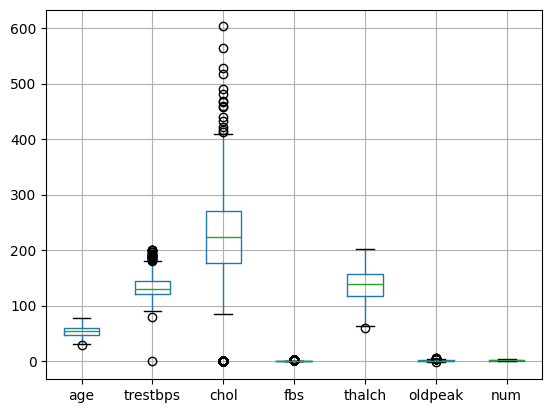

In [5]:
df.boxplot()

<Axes: xlabel='num', ylabel='count'>

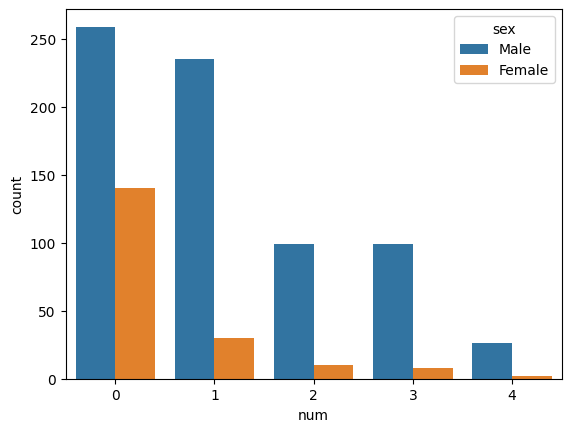

In [6]:
sns.countplot(x=df['num'],hue='sex',data=df)

(array([172.,   6.,  60., 309., 247.,  85.,  17.,   7.,   3.,   2.]),
 array([  0. ,  60.3, 120.6, 180.9, 241.2, 301.5, 361.8, 422.1, 482.4,
        542.7, 603. ]),
 <BarContainer object of 10 artists>)

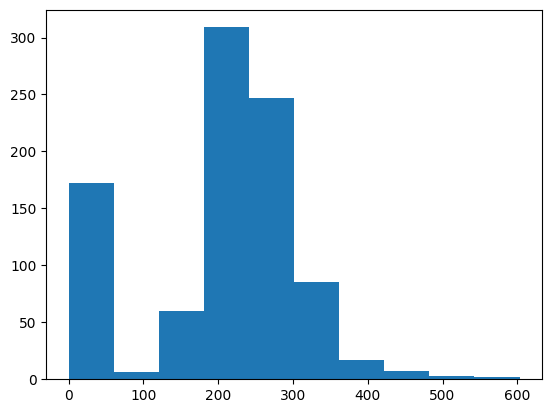

In [7]:
plt.hist(x=df['chol'])

<Axes: xlabel='cp'>

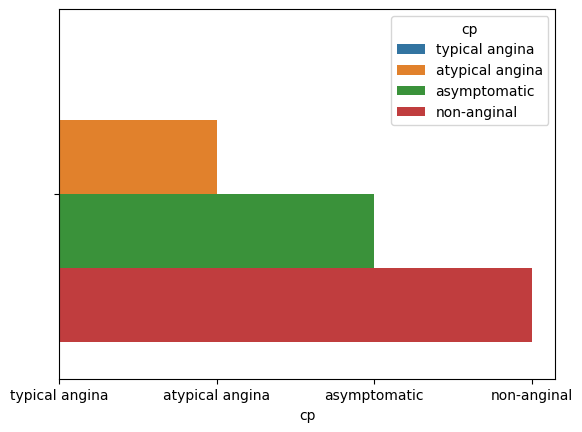

In [8]:
sns.barplot(x=df['cp'],data=df,hue='cp')

In [9]:
df.select_dtypes(include='object')

,sex,cp,restecg,exang,slope,thal
0,Male,typical angina,lv hypertrophy,False,downsloping,fixed defect
1,Male,atypical angina,normal,False,flat,fixed defect
2,Male,asymptomatic,normal,False,flat,fixed defect
3,Male,typical angina,lv hypertrophy,False,flat,fixed defect
4,Male,asymptomatic,normal,True,flat,fixed defect
...,...,...,...,...,...,...
903,Male,asymptomatic,normal,False,upsloping,fixed defect
904,Male,asymptomatic,st-t abnormality,True,flat,reversable defect
905,Male,non-anginal,lv hypertrophy,True,downsloping,fixed defect
906,Male,non-anginal,st-t abnormality,TURE,downsloping,reversable defect


Removing the outliers by iosolation forest

In [10]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.1,random_state=42)
num_col=df.select_dtypes(include='int')
df['Outliers']=iso.fit_predict(num_col)
cleaned_data=df.loc[df['Outliers']==1]
cleaned_data.reset_index(drop=True,inplace=True)

In [11]:
cleaned_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num,Outliers
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.300000,downsloping,fixed defect,0,1
1,41,Male,atypical angina,135,203,False,normal,132,False,0.000000,flat,fixed defect,0,1
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.400000,flat,fixed defect,0,1
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.000000,flat,fixed defect,0,1
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.500000,flat,fixed defect,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,65,Male,asymptomatic,126,312,False,lv hypertrophy,156,FALSE,0.891253,downsloping,fixed defect,3,1
813,51,Male,non-anginal,151,339,False,normal,122,FALSE,0.891253,upsloping,reversable defect,3,1
814,69,Male,asymptomatic,154,289,True,st-t abnormality,128,TURE,0.891253,flat,normal,3,1
815,64,Male,asymptomatic,145,212,False,lv hypertrophy,132,False,2.000000,flat,fixed defect,4,1


In [12]:
from sklearn.preprocessing import LabelEncoder

cat_col=cleaned_data.select_dtypes(include='object').columns
for column in cat_col:
    cleaned_data[column]=cleaned_data[column].astype(str)
    encoder=LabelEncoder()
    cleaned_data[column]=encoder.fit_transform(cleaned_data[column])

C:\Users\shyam\AppData\Local\Temp\ipykernel_17248\2512333128.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data[column]=cleaned_data[column].astype(str)
C:\Users\shyam\AppData\Local\Temp\ipykernel_17248\2512333128.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data[column]=encoder.fit_transform(cleaned_data[column])
C:\Users\shyam\AppData\Local\Temp\ipykernel_17248\2512333128.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

In [13]:
df['exang'].value_counts()

exang
False    516
True     337
TURE      36
FALSE     19
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
x=cleaned_data.drop(columns=['num','Outliers'])
y=cleaned_data['num']
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [15]:
gini_model=DecisionTreeClassifier(criterion='gini',max_depth=5)
gini_model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5)

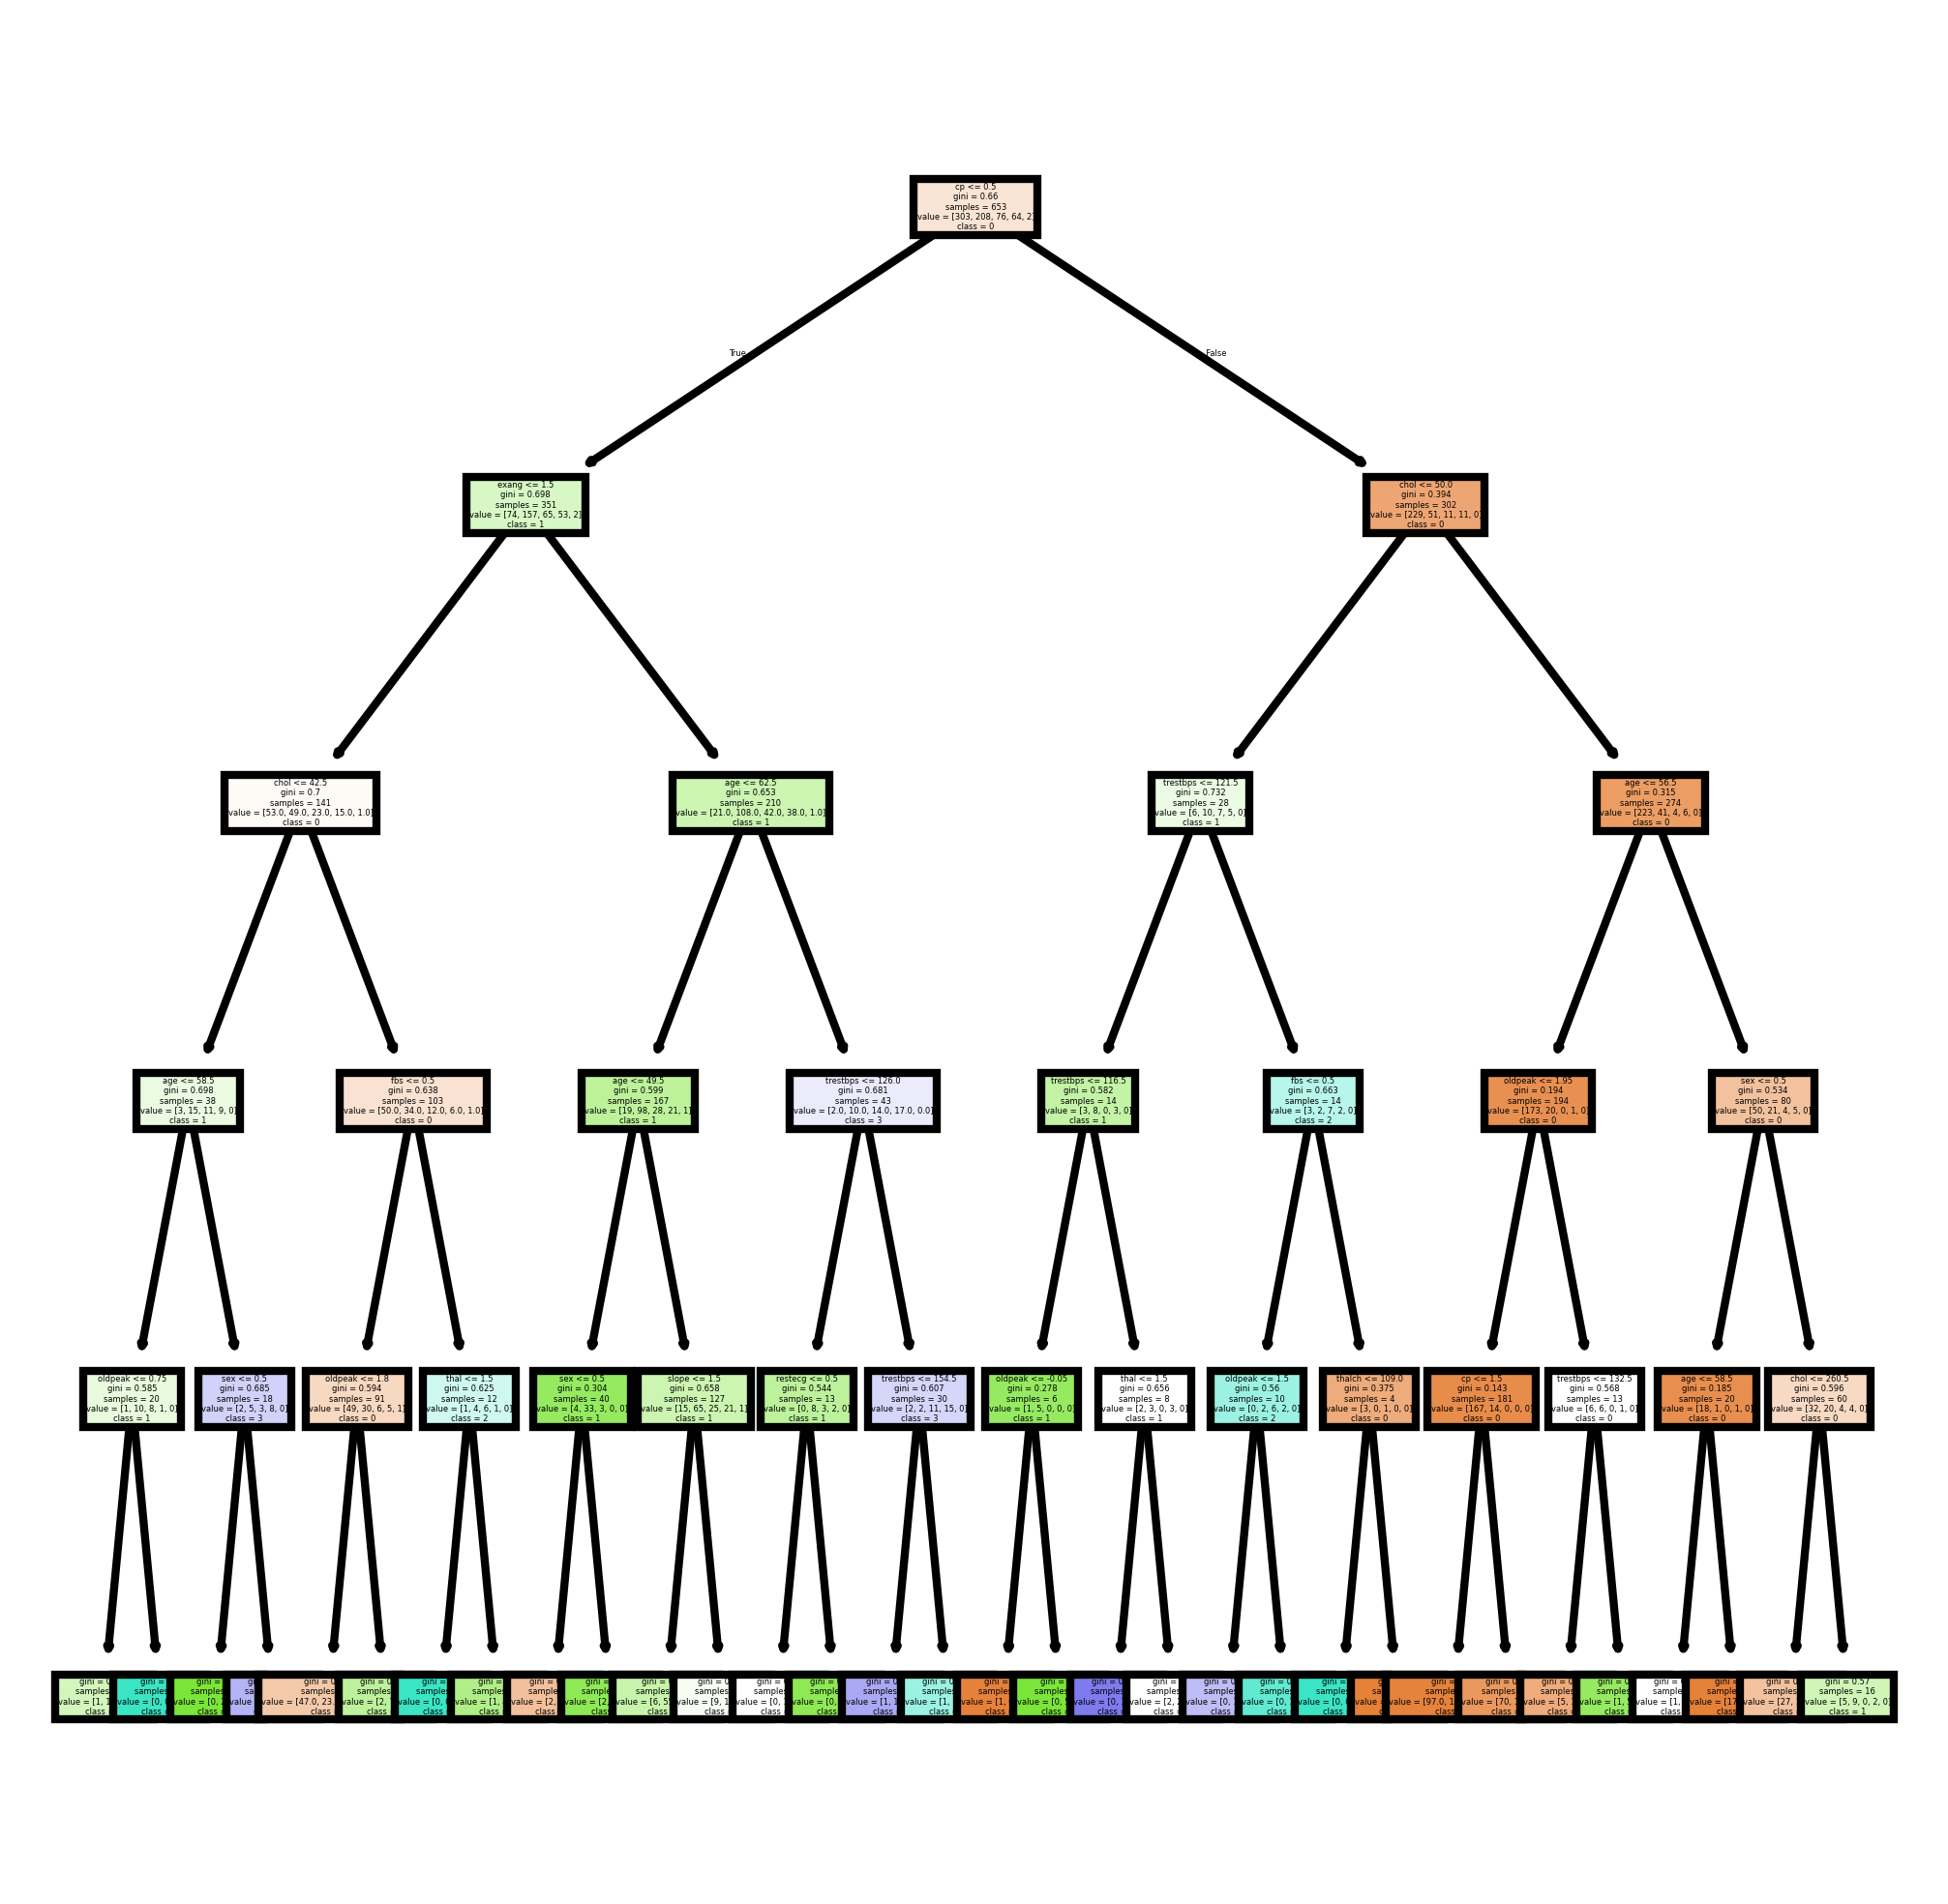

In [16]:
x_list=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch','exang', 'oldpeak', 'slope', 'thal']
y_list=['0','1','2','3','4']
fig,axes=plt.subplots(nrows=1,ncols=1,figsize=(4,4),dpi=600)
tree.plot_tree(gini_model,feature_names=x_list,class_names=y_list,filled=True)
plt.show()

In [17]:
pd.Series(gini_model.feature_importances_,index=x_list).sort_values(ascending=False)

cp          0.401147
age         0.128429
chol        0.122633
trestbps    0.073087
oldpeak     0.069950
exang       0.054452
sex         0.039851
fbs         0.037205
thal        0.036394
slope       0.015733
restecg     0.012385
thalch      0.008734
dtype: float64

In [18]:
g_preds=gini_model.predict(x_test)
pd.Series(g_preds).value_counts

<bound method IndexOpsMixin.value_counts of 0      1
1      3
2      0
3      1
4      1
      ..
159    1
160    1
161    1
162    1
163    0
Length: 164, dtype: int64>

In [19]:
pd.crosstab(y_test,g_preds)

col_0,0,1,2,3
num,,,,
0,62,14,0,0
1,16,23,1,7
2,8,11,2,3
3,3,12,2,0


In [20]:
print('Training Accuracy:',gini_model.score(x_train,y_train))
print('Testing Accuracy:',gini_model.score(x_test,y_test))

Training Accuracy: 0.7120980091883614
Testing Accuracy: 0.5304878048780488


In [21]:
entrphy_model=DecisionTreeClassifier(criterion='entropy',max_depth=6)
entrphy_model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6)

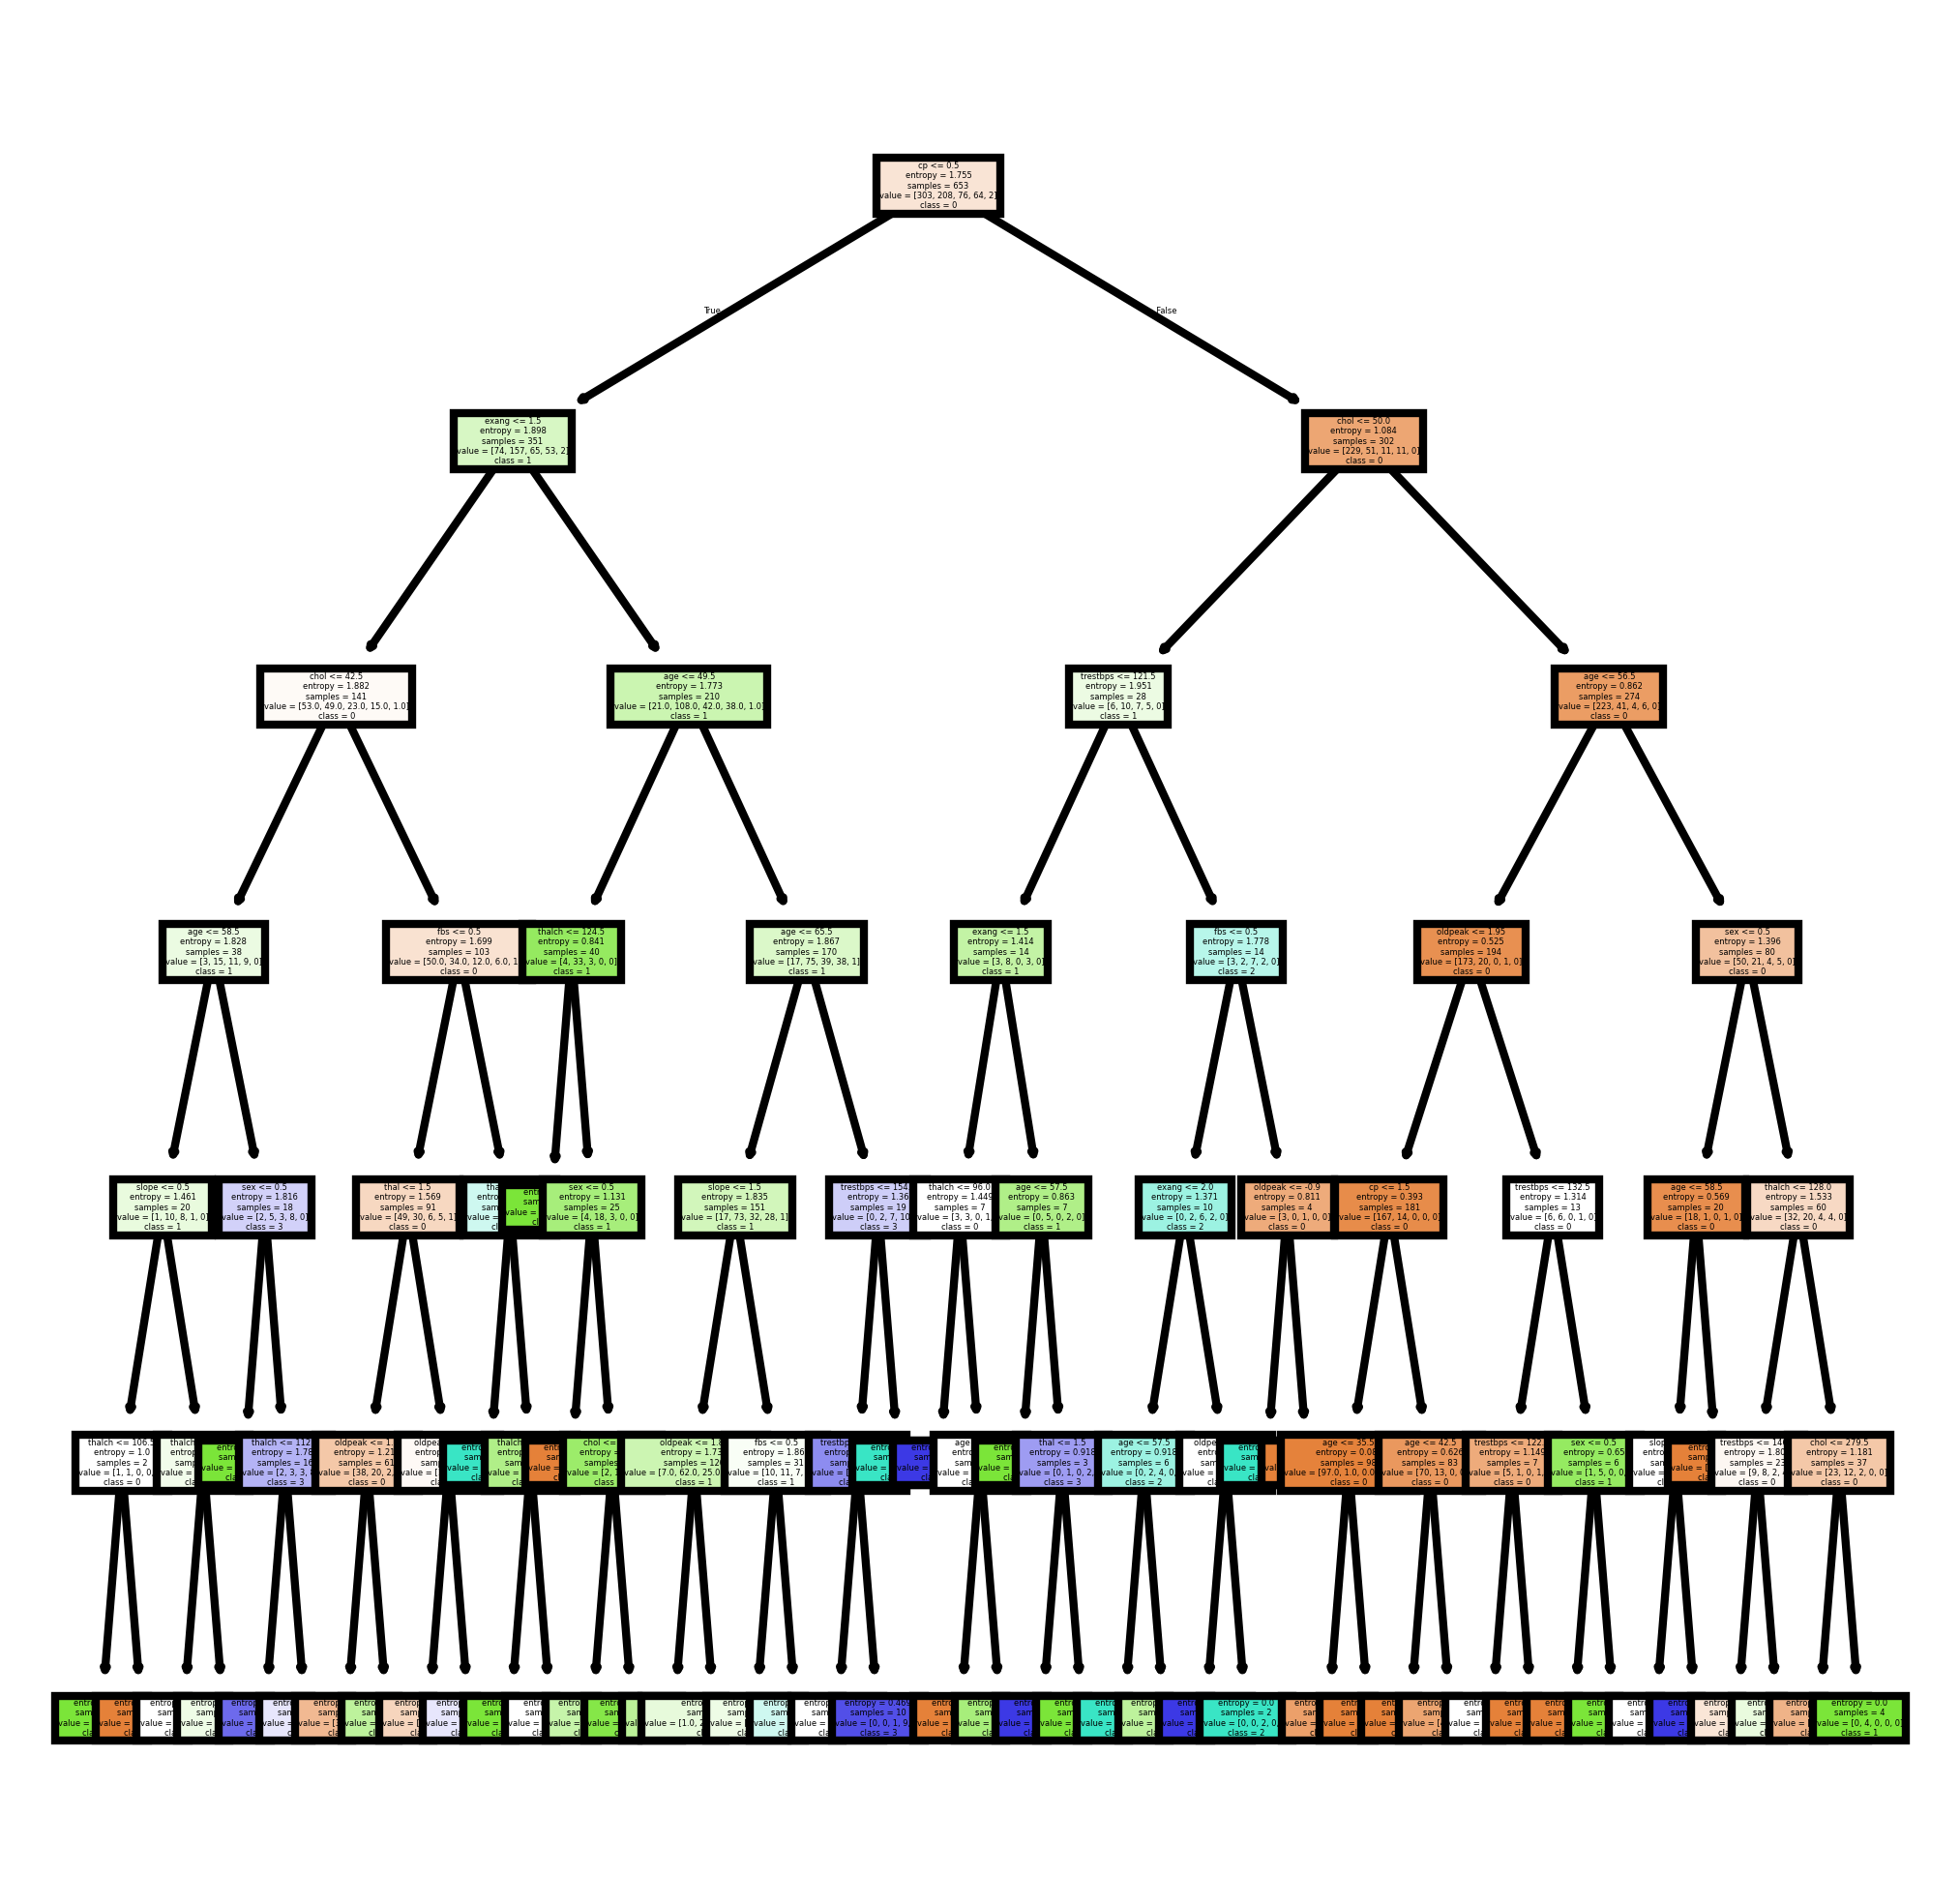

In [22]:
fig,axes=plt.subplots(nrows=1,ncols=1,figsize=(4,4),dpi=600)
tree.plot_tree(entrphy_model,feature_names=x_list,class_names=y_list,filled=True)
plt.show()

In [23]:
pd.Series(entrphy_model.feature_importances_,index=x_list).sort_values(ascending=False)

cp          0.284307
age         0.161511
chol        0.119808
oldpeak     0.080017
trestbps    0.070566
exang       0.062893
thalch      0.052500
fbs         0.049218
thal        0.047414
sex         0.039139
slope       0.032627
restecg     0.000000
dtype: float64

In [24]:
entrphy_preds=entrphy_model.predict(x_test)
pd.Series(entrphy_preds).value_counts()

0    85
1    65
3    10
2     4
Name: count, dtype: int64

In [25]:
pd.crosstab(y_test,entrphy_preds)

col_0,0,1,2,3
num,,,,
0,58,16,0,2
1,16,25,1,5
2,7,13,1,3
3,4,11,2,0


In [26]:
print('Training Accuracy:',entrphy_model.score(x_train,y_train))
print('Testing Accuracy:',entrphy_model.score(x_test,y_test))

Training Accuracy: 0.7274119448698315
Testing Accuracy: 0.5121951219512195


1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Ans:-  Max depth,minimum samples split,minimum sample leaf, maximum features , max lead nodes are the common hyper parameters. A higher value of ccp_alpha leads to the more aggressive pruning. to overfitting by cutting branches.

2. What is the difference between the Label encoding and One-hot encoding?

Ans:- in one hot encoding sub columns are generated for every category contains 0 and 1 .but, in the label encoding it gives uniqye labels for each category in the columns.